# 05A_scan_and_export_for_manual_filter_v2.ipynb

Đây là bản nâng cấp từ notebook scan cũ.

Notebook này vẫn giữ workflow cũ:
1. Đọc dữ liệu `emotion, pixels, Usage`
2. Quét toàn bộ ảnh
3. Gắn cờ `remove / review / suspect / ok`
4. Xuất ra 2 file CSV:
   - bản đầy đủ để bạn xem chi tiết
   - bản rút gọn `row_id, emotion, Usage` để bạn xóa thủ công

## Điểm nâng cấp chính
Ngoài các rule cũ (`mean/std/entropy/unique_count/...`), notebook này bổ sung thêm:

- `blur_score`: bắt ảnh mờ / mất cạnh
- `edge_density`: mật độ cạnh yếu, giúp bắt ảnh quá phẳng
- `border_dark_ratio`: viền đen bất thường
- `border_bright_ratio`: viền trắng bất thường
- `center_mean`, `border_mean`, `center_border_diff`: so sánh trung tâm và viền để phát hiện ảnh lệch sáng bất thường
- `center_dark_ratio`: trung tâm quá tối
- `center_bright_ratio`: trung tâm quá sáng

Mục tiêu là giảm bớt các trường hợp bị sót ở tầng scan tự động.


## 1. Import thư viện

In [19]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 260)


## 2. Cấu hình

In [20]:
DATA_PATH = '../../data/train.csv'  
OUTPUT_DIR = '../../data/cleaned_data'  
IMAGE_SIZE = 48
PIXEL_COUNT = IMAGE_SIZE * IMAGE_SIZE

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR)


Output dir: ../../data/cleaned_data


## 3. Đọc dữ liệu

In [21]:
def load_data(path):
    path = str(path)
    if path.lower().endswith('.csv'):
        df = pd.read_csv(path)
    elif path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        raise ValueError('Chỉ hỗ trợ .csv hoặc .xlsx/.xls')

    required_cols = {'emotion', 'pixels', 'Usage'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Thiếu cột: {missing}')

    df = df.copy()
    df['row_id'] = np.arange(len(df))
    return df

df = load_data(DATA_PATH)
print('Shape:', df.shape)
display(df.head())


Shape: (28709, 4)


,emotion,pixels,Usage,row_id
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,0
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,1
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,2
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,3
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,4


## 4. Parse pixel nhanh

In [22]:
def parse_pixels_fast(pixel_str):
    return np.fromstring(str(pixel_str), dtype=np.uint8, sep=' ')

sample_arr = parse_pixels_fast(df.loc[0, 'pixels'])
print('Số pixel sample:', len(sample_arr))
print(sample_arr[:20])


Số pixel sample: 2304
[ 70  80  82  72  58  58  60  63  54  58  60  48  89 115 121 119 115 110
  98  91]


## 5. Hàm đo đặc trưng ảnh

In [23]:
def compute_entropy(arr):
    if len(arr) == 0:
        return np.nan
    hist = np.bincount(arr, minlength=256).astype(np.float64)
    prob = hist / hist.sum()
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())

def compute_blur_score(img):
    # Laplacian variance bằng NumPy, không cần OpenCV
    img = img.astype(np.float32)
    lap = (
        -4 * img
        + np.roll(img, 1, axis=0)
        + np.roll(img, -1, axis=0)
        + np.roll(img, 1, axis=1)
        + np.roll(img, -1, axis=1)
    )
    # bỏ ảnh hưởng wrap-around ở biên
    lap[0, :] = 0
    lap[-1, :] = 0
    lap[:, 0] = 0
    lap[:, -1] = 0
    return float(lap.var())

def compute_edge_density(img, threshold=12.0):
    img = img.astype(np.float32)
    gx = np.zeros_like(img, dtype=np.float32)
    gy = np.zeros_like(img, dtype=np.float32)

    gx[:, 1:-1] = img[:, 2:] - img[:, :-2]
    gy[1:-1, :] = img[2:, :] - img[:-2, :]

    mag = np.sqrt(gx**2 + gy**2)
    return float((mag > threshold).mean())

def extract_border_and_center_stats(img, border_width=4):
    h, w = img.shape

    mask_border = np.zeros((h, w), dtype=bool)
    mask_border[:border_width, :] = True
    mask_border[-border_width:, :] = True
    mask_border[:, :border_width] = True
    mask_border[:, -border_width:] = True

    border = img[mask_border]
    center = img[~mask_border]

    border_mean = float(border.mean()) if len(border) else np.nan
    center_mean = float(center.mean()) if len(center) else np.nan
    center_border_diff = float(abs(center_mean - border_mean)) if len(border) and len(center) else np.nan

    border_dark_ratio = float((border < 10).mean()) if len(border) else np.nan
    border_bright_ratio = float((border > 245).mean()) if len(border) else np.nan
    center_dark_ratio = float((center < 10).mean()) if len(center) else np.nan
    center_bright_ratio = float((center > 245).mean()) if len(center) else np.nan

    return {
        'border_mean': border_mean,
        'center_mean': center_mean,
        'center_border_diff': center_border_diff,
        'border_dark_ratio': border_dark_ratio,
        'border_bright_ratio': border_bright_ratio,
        'center_dark_ratio': center_dark_ratio,
        'center_bright_ratio': center_bright_ratio,
    }


## 6. Hàm scan nâng cấp

4 mức cờ:
- `remove`: rất đáng nghi
- `review`: đáng nghi vừa
- `suspect`: đáng nghi nhẹ, tránh bỏ sót
- `ok`: chưa thấy bất thường lớn

Bạn có thể tinh chỉnh ngưỡng trong phần rule.


In [24]:
def scan_image_quality_v2(pixel_str):
    arr = parse_pixels_fast(pixel_str)

    if len(arr) != PIXEL_COUNT:
        return {
            'flag': 'remove',
            'reason': 'wrong_length',
            'pixel_count': len(arr),
            'mean': np.nan,
            'std': np.nan,
            'min': np.nan,
            'max': np.nan,
            'unique_count': 0,
            'zero_ratio': np.nan,
            'white_ratio': np.nan,
            'entropy': np.nan,
            'blur_score': np.nan,
            'edge_density': np.nan,
            'border_mean': np.nan,
            'center_mean': np.nan,
            'center_border_diff': np.nan,
            'border_dark_ratio': np.nan,
            'border_bright_ratio': np.nan,
            'center_dark_ratio': np.nan,
            'center_bright_ratio': np.nan,
        }

    img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)

    mean_val = float(arr.mean())
    std_val = float(arr.std())
    min_val = int(arr.min())
    max_val = int(arr.max())
    unique_count = int(np.unique(arr).size)
    zero_ratio = float((arr == 0).mean())
    white_ratio = float((arr == 255).mean())
    entropy = compute_entropy(arr)

    blur_score = compute_blur_score(img)
    edge_density = compute_edge_density(img)

    border_stats = extract_border_and_center_stats(img)
    border_mean = border_stats['border_mean']
    center_mean = border_stats['center_mean']
    center_border_diff = border_stats['center_border_diff']
    border_dark_ratio = border_stats['border_dark_ratio']
    border_bright_ratio = border_stats['border_bright_ratio']
    center_dark_ratio = border_stats['center_dark_ratio']
    center_bright_ratio = border_stats['center_bright_ratio']

    # =========================
    # REMOVE: nghi rất mạnh
    # =========================
    if std_val < 1.5:
        flag, reason = 'remove', 'very_low_std'
    elif unique_count <= 3:
        flag, reason = 'remove', 'too_few_unique_values'
    elif mean_val < 5 or zero_ratio > 0.90:
        flag, reason = 'remove', 'almost_black'
    elif mean_val > 250 or white_ratio > 0.90:
        flag, reason = 'remove', 'almost_white'
    elif entropy < 0.30:
        flag, reason = 'remove', 'very_low_entropy'
    elif blur_score < 8 and edge_density < 0.015 and std_val < 6:
        flag, reason = 'remove', 'dead_or_extremely_blurry'
    elif border_dark_ratio > 0.95 and center_dark_ratio > 0.85:
        flag, reason = 'remove', 'dark_everywhere'
    elif border_bright_ratio > 0.95 and center_bright_ratio > 0.85:
        flag, reason = 'remove', 'bright_everywhere'

    # =========================
    # REVIEW: nghi vừa
    # =========================
    elif std_val < 8:
        flag, reason = 'review', 'low_contrast'
    elif mean_val < 15:
        flag, reason = 'review', 'very_dark'
    elif mean_val > 240:
        flag, reason = 'review', 'very_bright'
    elif unique_count < 10:
        flag, reason = 'review', 'low_unique_values'
    elif entropy < 2.0:
        flag, reason = 'review', 'low_entropy'
    elif blur_score < 20:
        flag, reason = 'review', 'blurry'
    elif edge_density < 0.030:
        flag, reason = 'review', 'weak_edges'
    elif border_dark_ratio > 0.80 and center_border_diff > 35:
        flag, reason = 'review', 'dark_border'
    elif border_bright_ratio > 0.80 and center_border_diff > 35:
        flag, reason = 'review', 'bright_border'
    elif center_dark_ratio > 0.75 and mean_val < 35:
        flag, reason = 'review', 'dark_center'
    elif center_bright_ratio > 0.75 and mean_val > 220:
        flag, reason = 'review', 'bright_center'

    # =========================
    # SUSPECT: nghi nhẹ
    # =========================
    elif std_val < 12:
        flag, reason = 'suspect', 'slightly_low_contrast'
    elif mean_val < 25:
        flag, reason = 'suspect', 'slightly_dark'
    elif mean_val > 225:
        flag, reason = 'suspect', 'slightly_bright'
    elif unique_count < 18:
        flag, reason = 'suspect', 'slightly_low_unique_values'
    elif entropy < 3.2:
        flag, reason = 'suspect', 'slightly_low_entropy'
    elif blur_score < 35:
        flag, reason = 'suspect', 'slightly_blurry'
    elif edge_density < 0.050:
        flag, reason = 'suspect', 'slightly_weak_edges'
    elif border_dark_ratio > 0.60 and center_border_diff > 25:
        flag, reason = 'suspect', 'possible_dark_border'
    elif border_bright_ratio > 0.60 and center_border_diff > 25:
        flag, reason = 'suspect', 'possible_bright_border'
    else:
        flag, reason = 'ok', 'ok'

    return {
        'flag': flag,
        'reason': reason,
        'pixel_count': len(arr),
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'unique_count': unique_count,
        'zero_ratio': zero_ratio,
        'white_ratio': white_ratio,
        'entropy': entropy,
        'blur_score': blur_score,
        'edge_density': edge_density,
        'border_mean': border_mean,
        'center_mean': center_mean,
        'center_border_diff': center_border_diff,
        'border_dark_ratio': border_dark_ratio,
        'border_bright_ratio': border_bright_ratio,
        'center_dark_ratio': center_dark_ratio,
        'center_bright_ratio': center_bright_ratio,
    }


## 7. Quét toàn bộ dataset

In [25]:
scan_results = df['pixels'].apply(scan_image_quality_v2)
scan_metrics_df = pd.DataFrame(scan_results.tolist())

scan_df = pd.concat([
    df[['row_id', 'emotion', 'Usage', 'pixels']].copy(),
    scan_metrics_df
], axis=1)

print('Hoàn tất scan v2.')
display(scan_df.head())


Hoàn tất scan v2.


,row_id,emotion,Usage,pixels,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy,blur_score,edge_density,border_mean,center_mean,center_border_diff,border_dark_ratio,border_bright_ratio,center_dark_ratio,center_bright_ratio
0,0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,ok,ok,2304,117.592882,50.735357,11,210,190,0.000000,0.000000,7.316994,1488.144775,0.633247,93.407670,128.234375,34.826705,0.000000,0.000000,0.000000,0.0000
1,1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,ok,ok,2304,126.971354,40.854364,0,219,214,0.001736,0.000000,7.231241,2654.641602,0.809028,142.633523,120.080000,22.553523,0.000000,0.000000,0.020000,0.0000
2,2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,ok,ok,2304,160.814236,74.711745,0,255,254,0.015625,0.009549,7.670950,2260.359375,0.747830,131.126420,173.876875,42.750455,0.072443,0.106534,0.021875,0.0725
3,3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,ok,ok,2304,130.503472,59.357461,12,235,214,0.000000,0.000000,7.327695,2307.713135,0.627170,132.348011,129.691875,2.656136,0.000000,0.000000,0.000000,0.0000
4,4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,ok,ok,2304,97.900174,70.166311,0,241,234,0.077257,0.000000,7.488916,1823.946777,0.725260,54.071023,117.185000,63.113977,0.268466,0.000000,0.063750,0.0000


## 8. Thống kê kết quả

In [26]:
print('Phân bố flag:')
display(scan_df['flag'].value_counts())

print('\nPhân bố reason:')
display(scan_df['reason'].value_counts().head(30))

print('\nPhân bố theo Usage và flag:')
display(pd.crosstab(scan_df['Usage'], scan_df['flag']))


Phân bố flag:


flag
ok         28467
suspect      182
review        46
remove        14
Name: count, dtype: int64


Phân bố reason:


reason
ok                        28467
possible_dark_border        102
possible_bright_border       62
very_bright                  18
dark_border                  14
very_low_std                 12
slightly_bright              12
bright_border                 8
slightly_dark                 5
very_dark                     3
dark_center                   2
blurry                        1
slightly_low_contrast         1
almost_black                  1
dark_everywhere               1
Name: count, dtype: int64


Phân bố theo Usage và flag:


flag,ok,remove,review,suspect
Usage,,,,
Training,28467,14,46,182


## 9. Xem nhanh các dòng bị gắn cờ

In [27]:
flagged_df = scan_df[scan_df['flag'] != 'ok'].copy()

display(flagged_df[[
    'row_id', 'emotion', 'Usage', 'flag', 'reason',
    'pixel_count', 'mean', 'std', 'min', 'max',
    'unique_count', 'zero_ratio', 'white_ratio', 'entropy',
    'blur_score', 'edge_density', 'border_mean', 'center_mean',
    'center_border_diff', 'border_dark_ratio', 'border_bright_ratio',
    'center_dark_ratio', 'center_bright_ratio'
]].head(30))


,row_id,emotion,Usage,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy,blur_score,edge_density,border_mean,center_mean,center_border_diff,border_dark_ratio,border_bright_ratio,center_dark_ratio,center_bright_ratio
59,59,2,Training,review,dark_center,2304,22.118924,61.149661,0,255,153,0.759983,0.023003,2.238288,4598.193359,0.180556,16.383523,24.642500,8.258977,0.856534,0.028409,0.801875,0.043125
114,114,3,Training,suspect,possible_dark_border,2304,79.461372,79.458100,0,227,226,0.071615,0.000000,6.764410,2128.879883,0.570747,22.248580,104.635000,82.386420,0.748580,0.000000,0.208750,0.000000
116,116,4,Training,suspect,possible_dark_border,2304,49.079861,64.119177,0,201,201,0.452691,0.000000,4.971311,1135.069824,0.452257,17.316761,63.055625,45.738864,0.786932,0.000000,0.436875,0.000000
317,317,4,Training,suspect,possible_dark_border,2304,76.776042,92.699214,0,255,245,0.001302,0.003472,6.173742,1408.681030,0.464844,25.482955,99.345000,73.862045,0.629261,0.011364,0.256250,0.141250
1298,1298,4,Training,suspect,possible_dark_border,2304,81.182292,86.637935,0,255,245,0.001302,0.000434,6.701557,2797.609131,0.518663,31.633523,102.983750,71.350227,0.606534,0.007102,0.223750,0.000625
1392,1392,0,Training,suspect,possible_dark_border,2304,54.716580,56.330829,0,249,213,0.246962,0.000000,6.342174,2974.280029,0.665799,23.248580,68.562500,45.313920,0.634943,0.000000,0.220000,0.000625
1645,1645,4,Training,suspect,possible_dark_border,2304,36.240885,62.656683,0,215,203,0.372396,0.000000,4.697749,1425.945557,0.357205,16.092330,45.106250,29.013920,0.875000,0.000000,0.575000,0.000000
1714,1714,6,Training,suspect,possible_dark_border,2304,107.855469,88.391915,0,241,240,0.137587,0.000000,6.853806,3163.173096,0.622396,50.367898,133.150000,82.782102,0.644886,0.000000,0.162500,0.000000
1868,1868,2,Training,suspect,possible_bright_border,2304,168.892361,85.338708,0,255,250,0.006510,0.047309,6.514963,5970.351074,0.578993,216.684659,147.863750,68.820909,0.009943,0.744318,0.016250,0.225000
2059,2059,5,Training,review,very_bright,2304,245.425781,21.609312,86,255,122,0.000000,0.051215,3.504083,2190.448486,0.164062,246.150568,245.106875,1.043693,0.000000,0.818182,0.000000,0.884375


## 10. Hàm trực quan ảnh theo flag

In [28]:
def show_flagged_images(dataframe, label='review', n=25, random_state=42):
    subset = dataframe[dataframe['flag'] == label].copy()
    if len(subset) == 0:
        print(f'Không có ảnh nào thuộc nhóm: {label}')
        return

    if len(subset) > n:
        subset = subset.sample(n=n, random_state=random_state)

    subset = subset.reset_index(drop=True)

    cols = 5
    rows = math.ceil(len(subset) / cols)

    plt.figure(figsize=(15, 3 * rows))
    for i, row in subset.iterrows():
        arr = parse_pixels_fast(row['pixels'])
        if len(arr) != PIXEL_COUNT:
            continue
        img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(
            f"id={row['row_id']}\n{row['flag']} | {row['reason']}\nblur={row['blur_score']:.1f}, edge={row['edge_density']:.3f}"
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()


## 11. Trực quan theo từng nhóm

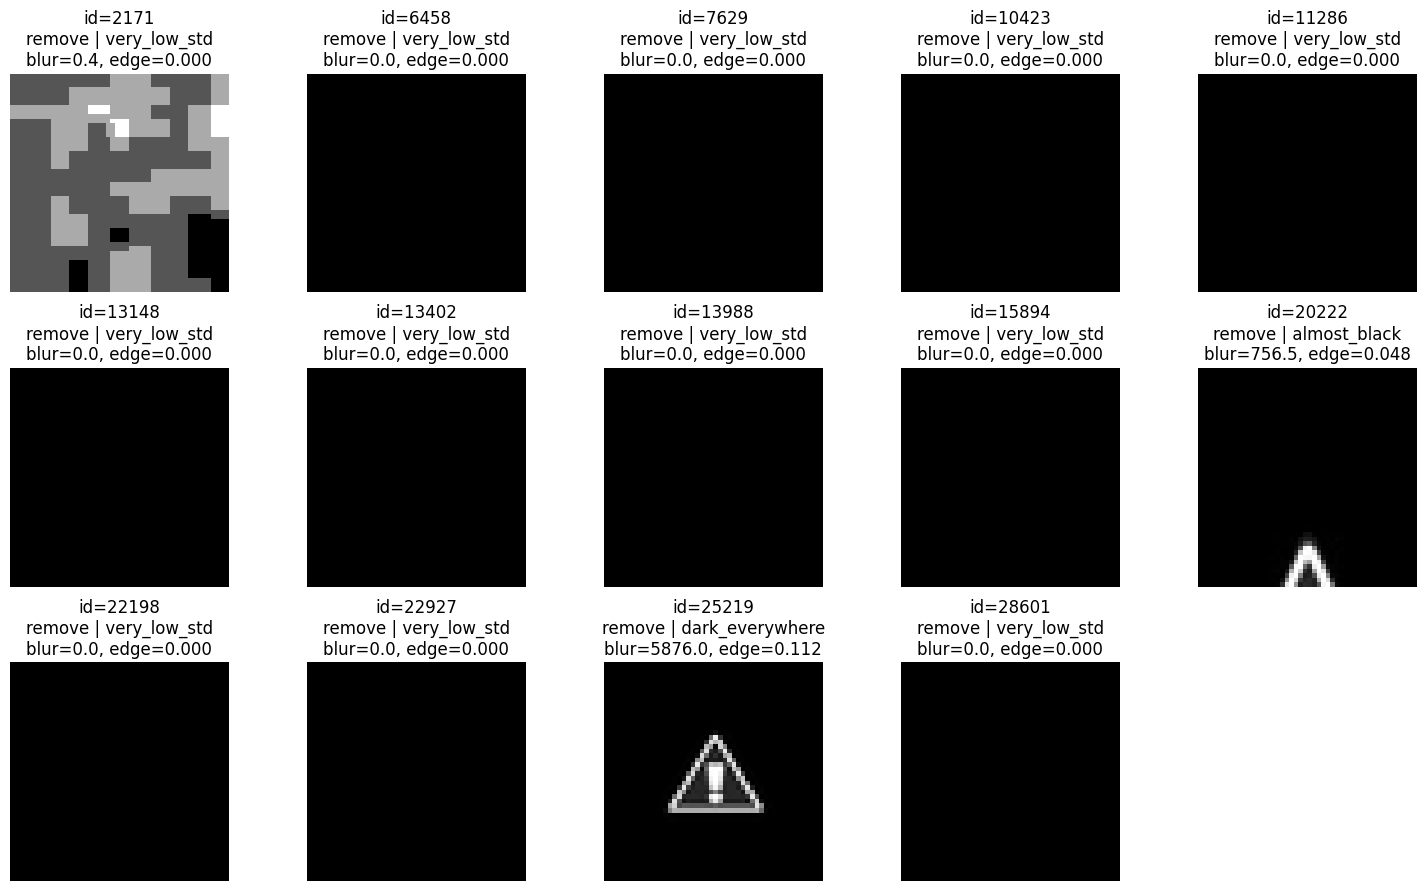

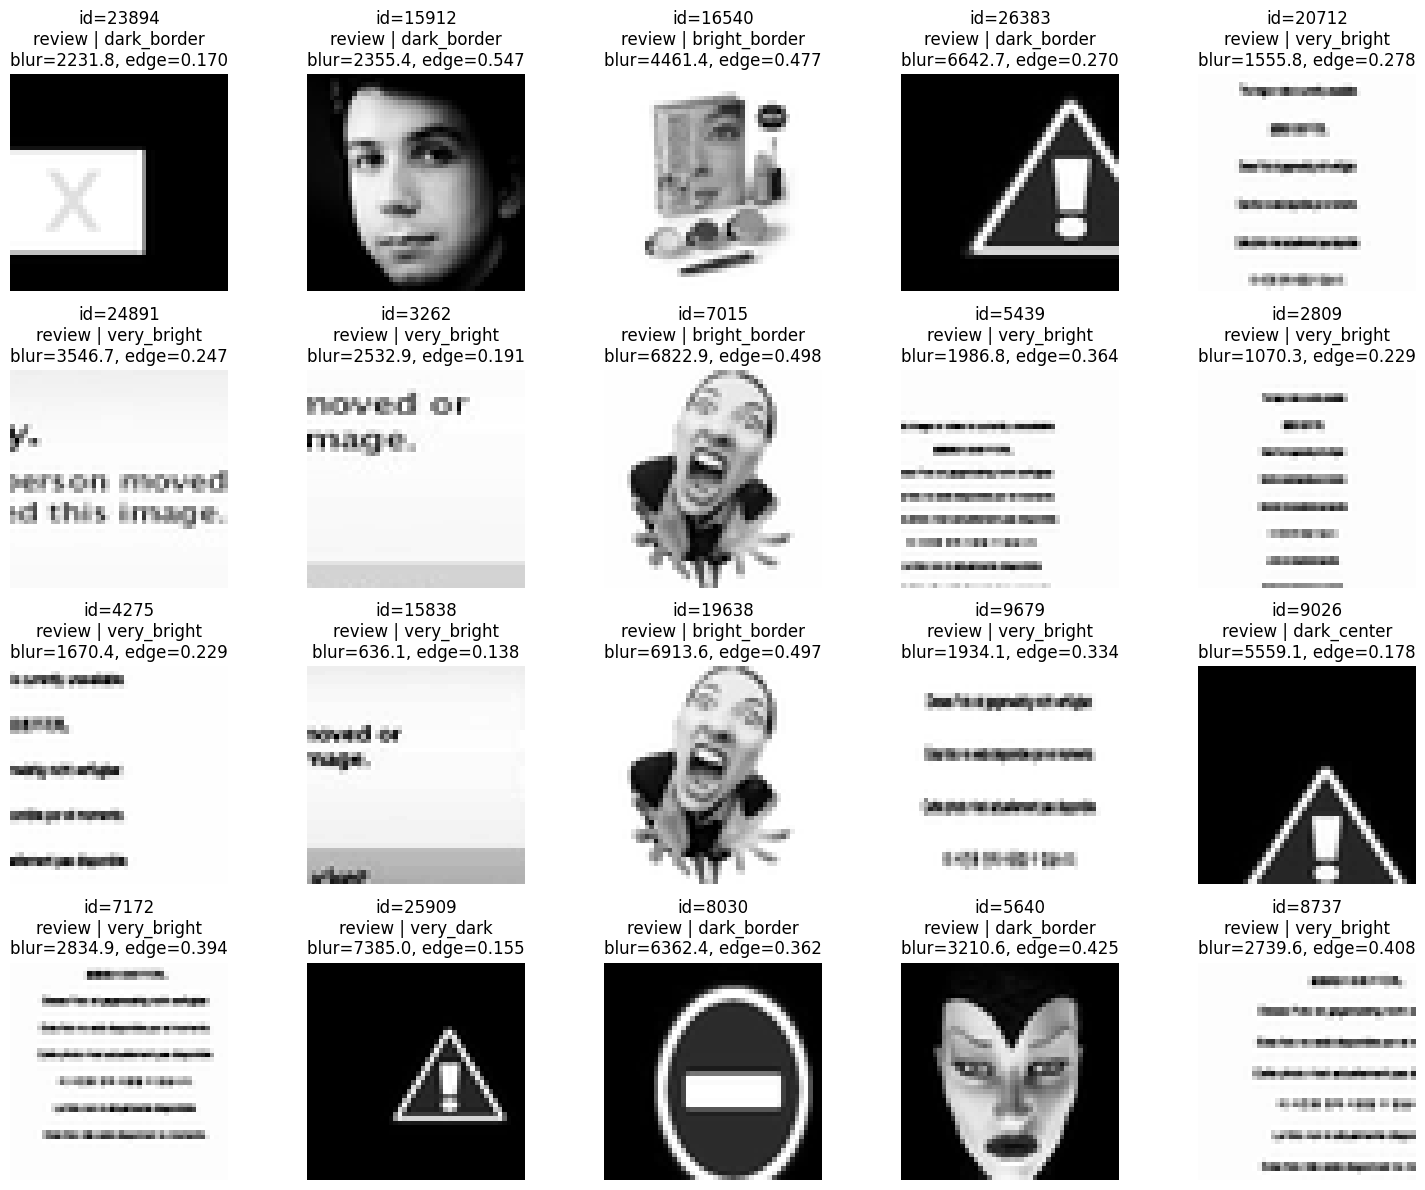

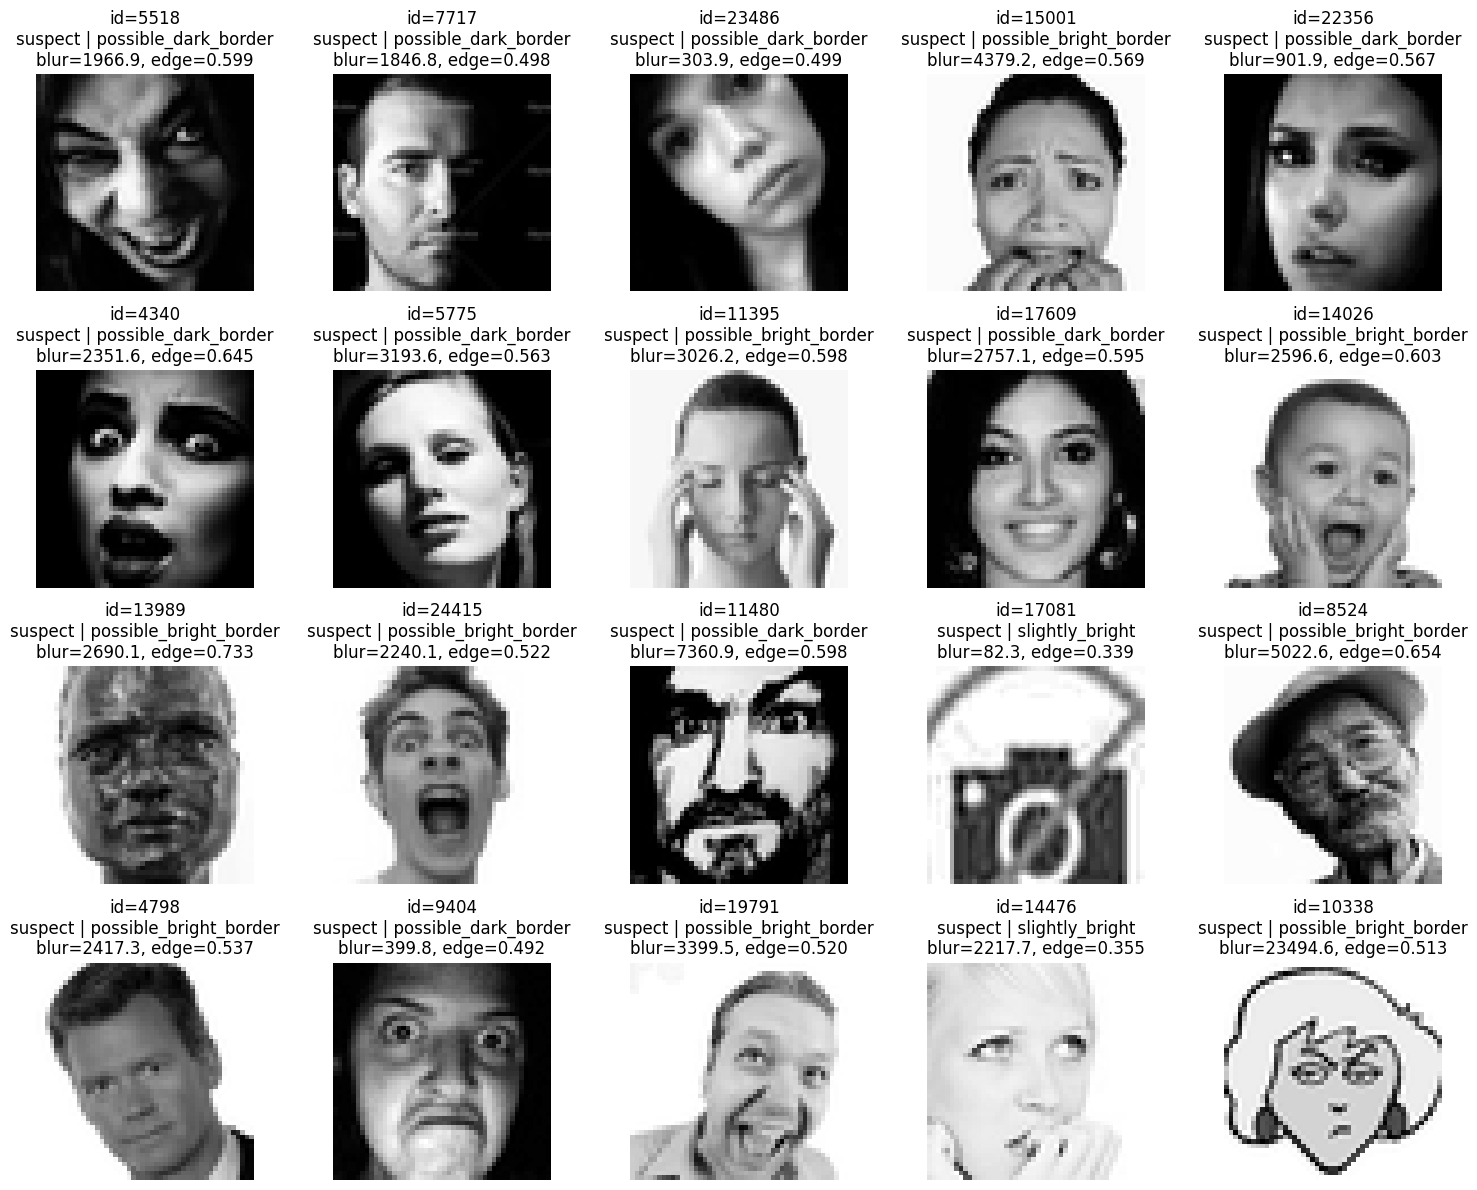

In [29]:
show_flagged_images(scan_df, label='remove', n=20)
show_flagged_images(scan_df, label='review', n=20)
show_flagged_images(scan_df, label='suspect', n=20)


## 12. Xem một ảnh cụ thể theo row_id

In [30]:
def show_image_by_row_id(dataframe, row_id):
    row = dataframe[dataframe['row_id'] == row_id]
    if len(row) == 0:
        print('Không tìm thấy row_id:', row_id)
        return

    row = row.iloc[0]
    arr = parse_pixels_fast(row['pixels'])

    if len(arr) != PIXEL_COUNT:
        print('Ảnh sai số lượng pixel:', len(arr))
        return

    img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(
        f"row_id={row['row_id']}, emotion={row['emotion']}, Usage={row['Usage']}\n"
        f"flag={row['flag']}, reason={row['reason']}\n"
        f"blur={row['blur_score']:.1f}, edge={row['edge_density']:.3f}"
    )
    plt.axis('off')
    plt.show()

    cols_to_show = [
        'row_id', 'emotion', 'Usage', 'flag', 'reason',
        'mean', 'std', 'entropy', 'blur_score', 'edge_density',
        'border_mean', 'center_mean', 'center_border_diff',
        'border_dark_ratio', 'border_bright_ratio',
        'center_dark_ratio', 'center_bright_ratio'
    ]
    display(row[cols_to_show].to_frame().T)


In [31]:
# Ví dụ:
# show_image_by_row_id(scan_df, 123)


## 13. Xuất CSV đầy đủ

Bản này để bạn xem chi tiết các metric.


In [32]:
full_export_df = scan_df[[
    'row_id', 'emotion', 'Usage', 'flag', 'reason',
    'pixel_count', 'mean', 'std', 'min', 'max',
    'unique_count', 'zero_ratio', 'white_ratio', 'entropy',
    'blur_score', 'edge_density', 'border_mean', 'center_mean',
    'center_border_diff', 'border_dark_ratio', 'border_bright_ratio',
    'center_dark_ratio', 'center_bright_ratio'
]].copy()

full_export_path = Path(OUTPUT_DIR) / 'scan_full_flags_v2.csv'
full_export_df.to_csv(full_export_path, index=False)

print('Đã lưu:', full_export_path)
display(full_export_df.head())


Đã lưu: ..\..\data\cleaned_data\scan_full_flags_v2.csv


,row_id,emotion,Usage,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy,blur_score,edge_density,border_mean,center_mean,center_border_diff,border_dark_ratio,border_bright_ratio,center_dark_ratio,center_bright_ratio
0,0,0,Training,ok,ok,2304,117.592882,50.735357,11,210,190,0.000000,0.000000,7.316994,1488.144775,0.633247,93.407670,128.234375,34.826705,0.000000,0.000000,0.000000,0.0000
1,1,0,Training,ok,ok,2304,126.971354,40.854364,0,219,214,0.001736,0.000000,7.231241,2654.641602,0.809028,142.633523,120.080000,22.553523,0.000000,0.000000,0.020000,0.0000
2,2,2,Training,ok,ok,2304,160.814236,74.711745,0,255,254,0.015625,0.009549,7.670950,2260.359375,0.747830,131.126420,173.876875,42.750455,0.072443,0.106534,0.021875,0.0725
3,3,4,Training,ok,ok,2304,130.503472,59.357461,12,235,214,0.000000,0.000000,7.327695,2307.713135,0.627170,132.348011,129.691875,2.656136,0.000000,0.000000,0.000000,0.0000
4,4,6,Training,ok,ok,2304,97.900174,70.166311,0,241,234,0.077257,0.000000,7.488916,1823.946777,0.725260,54.071023,117.185000,63.113977,0.268466,0.000000,0.063750,0.0000


## 14. Xuất CSV rút gọn để xóa thủ công

File này chỉ chứa các dòng bị gắn cờ:
- `remove`
- `review`
- `suspect`

Bạn sẽ tự xóa bớt các dòng muốn giữ lại.


In [33]:
manual_remove_candidate_df = scan_df[scan_df['flag'] != 'ok'][[
    'row_id', 'emotion', 'Usage'
]].copy()

manual_remove_candidate_path = Path(OUTPUT_DIR) / 'manual_remove_candidates_v2.csv'
manual_remove_candidate_df.to_csv(manual_remove_candidate_path, index=False)

print('Đã lưu:', manual_remove_candidate_path)
display(manual_remove_candidate_df.head())


Đã lưu: ..\..\data\cleaned_data\manual_remove_candidates_v2.csv


,row_id,emotion,Usage
59,59,2,Training
114,114,3,Training
116,116,4,Training
317,317,4,Training
1298,1298,4,Training


## 15. Hàm hỗ trợ đọc file remove list khi train

In [34]:
def load_row_ids_to_remove(path):
    remove_df = pd.read_csv(path)
    required_cols = {'row_id', 'emotion', 'Usage'}
    missing = required_cols - set(remove_df.columns)
    if missing:
        raise ValueError(f'Thiếu cột trong file remove list: {missing}')
    return set(remove_df['row_id'].astype(int).tolist())

# Ví dụ:
# final_remove_ids = load_row_ids_to_remove(manual_remove_candidate_path)
# train_df = load_data(DATA_PATH)
# train_df_filtered = train_df[~train_df['row_id'].isin(final_remove_ids)].reset_index(drop=True)
# print(len(train_df), '->', len(train_df_filtered))


## 16. Gợi ý tinh chỉnh

Sau khi chạy:
1. Xem số lượng `remove/review/suspect`
2. Mở `scan_full_flags_v2.csv`
3. Xem các nhóm reason mới như:
   - `blurry`
   - `weak_edges`
   - `dark_border`
   - `bright_border`
   - `possible_dark_border`
4. Nếu thấy bắt quá tay, nới ngưỡng
5. Nếu thấy còn lọt nhiều, siết ngưỡng

Đây là bản scan mạnh hơn bản cũ, nhưng vẫn chỉ nên coi là bước shortlist trước khi quyết định thủ công.
